# Notebook 1B: Scaling Data and Exploring Structure with PCA

*Authored by Dr. Noelle Anderson in 2026*


## Introduction

In this notebook, you will continue working with the **METABRIC** breast cancer dataset that you cleaned in Notebook 1A. This time, the focus shifts from cleaning steps like missing-value handling and data encoding to two new ideas that show up often in machine learning workflows: **scaling** and **principal component analysis (PCA)**.

You may have seen PCA plots in biology, genomics, or biomedical research before, even if you have not worked with PCA directly yet. Usually they appear as scatter plots with **PC1** and **PC2** on the axes instead of original variables from the dataset. PCA gives us a way to take data with many measured variables and summarize it with a small number of new axes, so broader patterns are easier to see. That can help us notice whether some samples look similar, whether there may be loose subgroups, and whether any samples stand out.

In this notebook, we will use PCA as a tool for exploration and visualization. It can help us summarize structure in the dataset, but it does not prove that any pattern we see is biologically meaningful on its own, and it does not create clusters for us. Those questions will come later when we begin clustering.

By the end of today's notebook, you will be able to:
- load your cleaned METABRIC file from Google Drive
- explain what data **scaling** does and why it matters
- use the **scikit-learn** package to scale a dataset
- run **PCA** on the scaled METABRIC dataset
- interpret PCA plots, explained variance, and PCA loadings at a beginner level
- save a new scaled dataset for use in later notebooks

*As you work, focus on interpreting what you see, not just writing and running code.*

## Why use PCA (Principal Component Analysis)?

The METABRIC dataset contains many measurements for each patient. When a dataset has many columns, when it is **high-dimensional**, it becomes hard to inspect the whole structure just by looking at the table directly.

It is easy to visualize **two variables at a time** with a 2-dimensional scatter plot. For example, we could compare **age at diagnosis** and **tumor size** and check whether patients with larger values in one also tend to have larger values in the other (what do you think? it doesn't look like there is based on the plot below!)

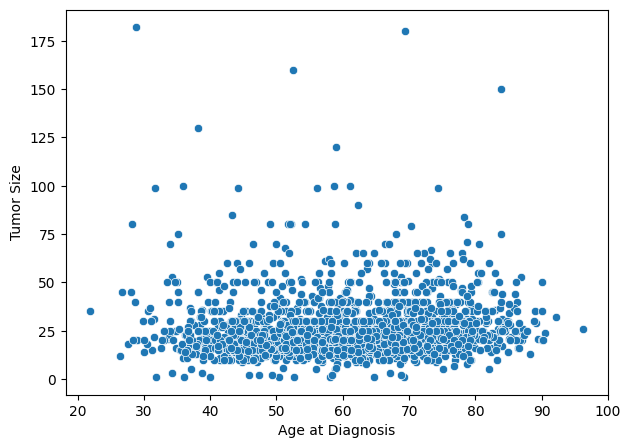


That kind of plot can still be useful, but it only shows us one small slice of the dataset at a time. Once we have many variables, we can no longer fully visualize the dataset with one simple 2D plot, and higher-dimensional plots quickly become hard to interpret.

PCA helps by creating new summary axes that combine information from many original variables at once. These new axes are called **principal components** (PCs).

A practical way to think about them is:

- **PC1** captures the strongest overall pattern of variation in the data  
- **PC2** captures the next strongest pattern in the data, but it has to capture something different from what PC1 already captured  

When we make a PCA plot, each point is still one patient, but the meaning of the axes is different. Instead of showing one original variable on each axis, we are plotting patients along new combined axes built from many variables at once.

PCA is part of **unsupervised learning**, where we are not trying to predict an answer column. Instead, we are asking whether the patient measurements themselves show broad patterns or structure.

PCA is often useful before methods like clustering because it gives us a simpler way to inspect overall structure in a high-dimensional dataset. At the same time, PCA is **not** clustering, and it does **not** prove that any pattern we see is biologically meaningful on its own.

If you would like another explanation of PCA alongside the notebook, this short optional video may help: [5-minute PCA video](https://www.youtube.com/watch?v=HMOI_lkzW08&t=27s). You do not need the linear algebra behind PCA for this course. The main goal here is to understand what PCA helps us do, what the axes mean at a basic level, and what kinds of conclusions we should and should not draw from a PCA plot.


## Notebook 1B roadmap

In this notebook, we will follow this workflow:

1. **Load the cleaned METABRIC data from 1A**
2. **Review the dataset structure**
3. **Compare value ranges before scaling**
4. **Run a brief PCA on the unscaled data as a cautionary example**
5. **Scale the dataset with scikit-learn**
6. **Run the main PCA analysis on the scaled data**
7. **Inspect explained variance**
8. **Inspect and interpret loadings**
9. **Reflect on what PCA can and cannot do**
10. **Save the scaled dataset for later notebooks**

## Step 0: Import needed packages


In [ ]:

# These are packages you will see often in this course
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# These are new to you today. They come from the scikit-learn package.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Notice that we are now importing from **scikit-learn**, often shortened to **sklearn**. This is one of the main Python libraries used for machine learning. We will use it many times later in the course, including in supervised learning, so today is a good place to start getting comfortable with its syntax.

## Step 1: Load the cleaned METABRIC data from Google Drive

At the end of Notebook 1A, you saved your cleaned dataset to your Google Drive. In this notebook, we will load that saved file so we can continue from the same starting point.

We will use the same folder path from 1A: `SCIP2026ML`.


### <font color=0D9488>**Question 1:**</font> Import and mount your Google Drive and load in your `metabric_1a_cleaned.csv` file from the `SCIP2026ML` folder. Make sure `patient_id` is the index.


In [ ]:
# Your solution here!


### <font color=0D9488>**Question 2:**</font> Print the shape of the dataframe, the index name, and the first 5 rows so you can confirm the dataset loaded correctly.


In [ ]:
# Your solution here!


This dataset should already be cleaned from 1A, so we are not repeating the earlier missing-value and binary-encoding steps here.

## Step 2: Review what kind of data we have

Each row still represents one patient, and each column is one measured variable for that patient. There is **no outcome column** here, which matters because we are not trying to predict anything yet.

That means this notebook is working in an **unsupervised** setting. We are asking whether the patient measurements themselves show broad patterns or structure.

Take a quick look at the dataframe structure with `df.info()`. This is a useful reminder of the column types before we use a method like PCA, which needs numeric input.

In [ ]:
# Quick reminder check
print(df.info())

## Step 3: Compare value ranges before scaling

A numeric **range** tells us the smallest and largest values in a column. This is an easy first way to see whether some variables are measured on very different scales.

For example, if one column mostly runs from 0 to 1 while another runs from about 0 to 150, the larger-scale column may have much more influence on methods like PCA and clustering if we do not scale the data first. That does **not** mean the larger-scale column is more biologically important. It may simply have bigger numbers.

We will look at four summary measures:

- `.min()` gives the smallest value
- `.max()` gives the largest value
- `.std()` gives the standard deviation, which measures how spread out the values are around the mean
- `.var()` gives the variance, which is another measure of spread

For now, focus mainly on the idea of **spread**. The key point is that some columns vary much more than others before scaling.

This matters because PCA is based on **variance**. So while min and max give us an easy first check, standard deviation and variance help explain which variables may dominate an unscaled PCA.

In [ ]:

example_cols = [
    'age_at_diagnosis',
    'tumor_size',
    'lymph_nodes_examined_positive',
    'neoplasm_histologic_grade'
]

spread_summary = pd.DataFrame({
    'min': df[example_cols].min(),
    'max': df[example_cols].max(),
    'std': df[example_cols].std(),
    'variance': df[example_cols].var()
})

display(spread_summary)


When you compare those ranges, notice that some variables, such as `tumor_size`, vary over much larger numeric scales than others, such as `neoplasm_histologic_grade`. That difference in **spread** is exactly what can distort methods like PCA when we have not scaled the data yet.

### Why scaling matters

These example ranges show that not all columns are measured on the same numeric scale. Some variables vary across much larger numbers than others.

That can be a problem because many data analysis methods are affected by the size and spread of the numbers in each column. If one column has a much larger range, it can have a much bigger influence on the result, even if it is not actually more important biologically. You will see that issue today in PCA, and the same general concern will matter later in clustering and in some supervised linear models.

**Scaling** puts columns onto a more comparable scale. In this notebook, we will use **standardization**, which transforms each column so it has:
- a mean close to **0**
- a standard deviation close to **1**

This may sound familiar from Notebook 1A. There, you saw a colorful boxplot of **z-scored** gene expression values. The same basic idea is used here: for each column, we subtract the column mean from every value and then divide by that column's standard deviation.

That does **not** erase the biology. It changes the scale so that variables with larger raw numbers do not automatically dominate methods that are sensitive to variation, spread, or distance.

### <font color=0D9488>**Question 3:**</font> Predict what might happen if we run PCA on the unscaled data. Which kinds of variables do you think may have the strongest influence, and why?

*Hint: You can inspect all columns with `.describe()`, or build a summary table of min, max, standard deviation, and variance for the whole dataframe.*

In [ ]:
# Your solution here!


**Your solution here!**


**Solution**

On the unscaled data, variables with the largest numeric spread will usually have the strongest influence on PCA. That is because PCA looks for directions of high variation. If one column varies over much larger numbers than the others, it can dominate the analysis even if it is not biologically the most important variable.


## Step 4: Run a BAD PCA: Using unscaled data

We will first run a very short PCA on the **unscaled** data. This is not the main PCA analysis for the notebook. It is a cautionary example that helps show why scaling is usually an important preprocessing step before PCA.

At a basic level, PCA is trying to find new ways to view the data that reveal the biggest patterns of variation. Instead of looking at each original variable separately, it builds new summary axes from combinations of the original variables that capture how patients differ from each other overall.

The points in the plot are still patients. Only the axes have changed.

In [ ]:
# Create a PCA tool that will find 2 principal components
# We choose 2 because we want to make a 2D plot
pca_unscaled = PCA(n_components=2)

# Fit PCA to the unscaled dataframe and transform the data
# into principal component coordinates
X_pca_unscaled = pca_unscaled.fit_transform(df)

# Put the PCA output into a dataframe so it is easier to work with
pca_unscaled_df = pd.DataFrame(
    X_pca_unscaled,
    index=df.index,
    columns=['PC1', 'PC2']
)

In [ ]:
# Get the explained variance ratio for PC1 and PC2
# These values tell us how much of the dataset's overall variation
# is captured by each principal component
unscaled_var = pca_unscaled.explained_variance_ratio_

# We'll explain this more below!

In [ ]:
# Make a scatter plot of the first two principal components
plt.figure(figsize=(7, 5))
plt.scatter(pca_unscaled_df['PC1'], pca_unscaled_df['PC2'], alpha=0.6)

# adding the explained variance %s to the axes with f-strings
plt.xlabel(f'PC1 ({unscaled_var[0]*100:.1f}% of variance)')
plt.ylabel(f'PC2 ({unscaled_var[1]*100:.1f}% of variance)')

plt.title('PCA of Unscaled METABRIC Data')
plt.show()

In this plot, each point is still one patient, but the axes are no longer original variables like age or tumor size. They are now **PC1** and **PC2**, which are new summary axes built by combining information from many columns in the dataset.


**Interpreting the PCA plot patterns**

When we run and plot a PCA, we look at the overall shape of the data: whether the points form one broad cloud or several smaller clouds, how spread out the points are, and whether any patients stand far away from the rest.

In this unscaled PCA plot, most patients fall into one broad cloud rather than several clearly separated groups. That does not mean the plot is useless, and it does not mean there are no meaningful patterns in the data, it just means those patterns are not very clearly separated in this 2D view.


**What do the variance percentages on the axes mean?**

You also saw us extract a result, `explained_variance_ratio_`, from the fitted PCA object to label the axes.

The percentages show the **explained variance ratio** for each principal component. This tells us how much of the dataset's overall variation is captured by that axis. In plain language, it tells us how much of the overall differences across patients are being summarized by that principal component, that new summarized axis.

Here, **PC1 captures 53.7%** of the variation in the data, and **PC2 captures 39.0%**. That means these two new axes summarize a lot of the overall differences across patients in the original dataset.

Together, PC1 and PC2 show about **92.7% of the total variation** in the dataset. That is a very large amount for just two axes!

But because this PCA was run on the **unscaled** data, we should be careful. Earlier, we saw that some variables have much larger numeric ranges than others. Since PCA looks for directions with the most variation, those larger-scale variables can strongly influence the first principal components.

So these high percentages do not automatically mean this is the best or fairest summary of the dataset. Also, capturing a lot of variation does not automatically mean the points will form clearly separated groups.

In the next step, we will scale the data and run PCA again so we can compare.

## Step 5: Scale the dataset with `StandardScaler`

Now we will scale the dataset so the variables can be compared more fairly and later produce a proper PCA analysis.

We will now use **`StandardScaler`** from scikit-learn to scale the dataset instead of doing that calculation manually.

Scaling is a common first step in many machine learning workflows when your data is on different scales and your methods are sensitive to things like distances, spread, or how much variables vary numerically.

A common `sklearn` preprocessing pattern is:

1. create the tool you want to use  
2. **fit** the tool to the data  
3. **transform** the data  

Here, **fit** means the tool looks at the data and learns whatever it needs before it can be used. In this case, it learns the mean and standard deviation of each column.

Then, **transform** means the tool uses what it learned to change the data. For standardization, it subtracts the column mean from each value and then divides by the column standard deviation.

You can think of it this way:

- **fit** = learn from the data  
- **transform** = apply that learning to the data  

A shortcut you will often see is **`fit_transform()`**, which does both steps together. You will see this same general pattern again later in machine learning, even when we are doing tasks other than scaling.


In [ ]:
# Create the scaling tool
scaler = StandardScaler()

In [ ]:
# Learn the scaling values from df and apply the transformation
X_scaled = scaler.fit_transform(df)

# Turn the scaled NumPy array back into a dataframe for readability
df_scaled = pd.DataFrame(X_scaled, index=df.index, columns=df.columns)

# View the summary
df_scaled.describe()

The scaled output is now on a standardized scale, so the values no longer represent the original units directly.

Now each scaled value tells us how far above or below the column average that patient is, measured in **standard deviations**. A value in our data near 0 means the patient is close to the column average. A positive value means the patient is above average for that variable, and a negative value means the patient is below average. Here we are just showing the summary using `describe` to show the std and mean.

This scaling is closely related to the idea of **z-scoring** that you saw for the gene expression data in Notebook 1A. Rescaling values in this way doesn't erase the real biology of the data, it just makes the columns more comparable so that variables with larger raw numbers do not automatically dominate later analyses.


After applying a large transformation, it is good practice to check the result and make sure the dataframe still has the structure we expect.

### <font color=0D9488>**Question 4:**</font> Check that the scaled dataframe still has the same shape, the same patient index, and the same column names. Then inspect the means and standard deviations of the first 5 scaled columns. What do you notice?

*Hint: Use `.mean()` and `.std()`.*


In [ ]:
# Your solution here!


**Your solution here!**


**Solution**

The scaled dataframe should still have the same rows, columns, and patient index as the original dataframe. What changes is the numeric scale of the values. The column means should now be very close to 0, and the standard deviations should be close to 1.


## Step 6: Run PCA correctly: On scaled data

Now we will apply PCA to `df_scaled`. This is the **main PCA analysis** for this notebook, because scaling makes the variables more comparable and reduces the distortion caused by very different raw ranges.

In Step 4, we used PCA on the unscaled data only as a quick comparison. Here, we are using PCA the right way, after putting the variables on a more comparable scale.

You will also notice the same general sklearn pattern again:
- create the PCA tool object
- fit it to the data (learning)
- transform the data into principal component coordinates
- inspect the results

### <font color=0D9488>**Question 5:**</font> Using the unscaled PCA code as a model, do the following with the **scaled** data:

- create and fit a new PCA object with 2 components called `pca`
- store the PCA output in a dataframe called `pca_df`
- extract the explained variance ratio
- make a scatter plot of PC1 and PC2 with axes labelled with the PC and the variance explained

In [ ]:
# Your solution here!

### <font color=0D9488>**Question 6:**</font> Compare the unscaled PCA plot to the scaled PCA plot. What changed? What patterns do you notice?


**Your solution here!**


**Why does the scaled PCA show clearer groupings even though the explained variance is lower?**

In the scaled PCA plot, the points show more visible structure: one main group, plus 1-2 more spread-out groups around it. That does **not** prove these are true biological groups, but it does make the plot easier to interpret.

The lower explained variance percentage does **not** automatically mean the scaled PCA plot is less useful.

In the unscaled PCA, a few variables with much larger numeric ranges can dominate the first principal components. That can make PC1 and PC2 explain a very large share of the variation, even if they are not giving the most balanced summary of the dataset.

After scaling, all variables contribute more fairly. That often lowers the explained variance of PC1 and PC2, because the variation is spread more *evenly* across more components. But it can also make the 2D plot easier to interpret, because the axes now reflect a more balanced summary of the dataset.


## Step 7: PCA Loadings

When the principal component axes are *mixes* of the variables, how can we know what variables are most strongly contributing to the patterns we see? **PCA loadings** tell us how strongly an original variable contributes to a given principal component.

**We interpret PCA loadings as:**
- a **larger absolute value** means that variable contributes more strongly to that component
- the **sign** tells us direction on the PCA axis, but signs should be interpreted carefully
- loadings help describe an axis, but they do **not** prove causation

First we will show you how to extract the loadings for PC1 from our scaled PCA we just made, then ask you to print the PC1 loadings from your unscaled PCA from step 4.

In [ ]:
# Create a loadings table for the scaled PCA
loadings_scaled = pd.DataFrame(
    pca.components_.T,  # Extract the PCA loadings with .components_ and transpose the matrix
    index=df.columns,   # Make our original colums indices in this df
    columns=['PC1', 'PC2'] # Make the columns the PC1 and PC2 values from .components_
)

# Add a temporary column with the absolute size of each PC1 loading, this is to help us sort below
loadings_scaled['abs_PC1'] = loadings_scaled['PC1'].abs()

# Sort by the size of the PC1 loading, largest first
loadings_scaled = loadings_scaled.sort_values(by='abs_PC1', ascending=False)

print('Top loadings for scaled PC1:')
display(loadings_scaled[['PC1']].head(10)) # print the actual loadings, not the absolute values

Here we see the estrogen and progesterone receptor status and 2 genes as the top loadings. This suggests that, after scaling, the main pattern captured by PC1 is being shaped by biologically meaningful differences in tumor characteristics and gene expression.

### <font color=0D9488>**Question 7:**</font> Now do the same for the unscaled data.

*Hint: we stored that in the variable `pca_unscaled`.*

In [ ]:
# Your solution here!

### <font color=0D9488>**Question 8:**</font> Compare the top PCA loadings between your scaled and unscaled data. Based on what you learned about PCA and scaling, why do you think tumor_size and age_at_diagnosis were top in the unscaled and not in the scaled PCA?


**Your solution here!**


## Step 8: What PCA can and cannot do

At this point, you have used PCA to summarize a high-dimensional biological dataset, compare unscaled and scaled results, inspect explained variance, and look at loadings. This is a good moment to pause and interpret responsibly.

**PCA can help us:**
- summarize many variables into a smaller number of axes
- visualize broad structure in a high-dimensional dataset
- prepare for later methods such as clustering

**PCA cannot:**
- automatically discover the one correct number of biological groups
- prove that visible patterns are clinically meaningful
- prove causation
- replace careful biological interpretation

That caution matters especially in biomedical datasets, where apparent patterns can also be shaped by measurement choices, preprocessing decisions, sample composition, and other sources of bias or limitation.

## Step 9: Save the scaled dataset

We will now save the scaled version of the METABRIC dataset for later notebooks.


Now save the scaled dataframe as `metabric_1b_scaled.csv` in the same Google Drive folder you used above. Printing the full save path is a good way to confirm where the file went and to make sure you will be able to find it easily next week.

Use the code cell below to save the file. Saving the file is an important workflow habit because we will use this scaled dataset again in the clustering notebook.

### <font color=0D9488>**Question 9:**</font> Save your scaled df to the filename `metabric_1b_scaled.csv` in your SCIP2026ML google drive folder.

In [ ]:
# Save the scaled dataframe
# Your solution here!


*Tip: In real machine learning workflows, it is very common to save important intermediate files after major preprocessing steps! Why re-do preprocessing, often the longest data handling step, when you can save your data in a clean reusable format?*

___

*Pro-tip: Another way to do this with models, not just files, is called **serialization**. It's beyond what we have time for in this short course, but I recommend learning it if you want to continue in ML. Here is an advanced notebook using supervised learning ML examples to demonstrate serialization: https://colab.research.google.com/drive/1SQP2XX-gDYosvQGHrIKuyMVuFAcNO7pg?usp=sharing*


# Congratulations, you have completed Notebook 1B!


## Key Takeaways from today

In this notebook, you:
- loaded the cleaned METABRIC dataset from Notebook 1A
- learned why **scaling** matters before PCA
- used **`StandardScaler`** from sklearn to standardize the dataset
- ran PCA on unscaled and scaled data and compared the results
- used **explained variance** to think about how much structure the first components capture
- inspected **loadings** to see which original variables contributed strongly to PC1
- saved a scaled dataset for use in later notebooks

One of the biggest ideas from this notebook is that PCA helps us summarize and visualize structure in the data, but interpreting what that structure means still requires caution and context.

## Where This Fits in the ML Workflow

This notebook focused on the middle part of an unsupervised machine learning workflow:

1. In **Notebook 1A**, you cleaned and prepared the METABRIC dataset
2. Here you added another preprocessing step, **scaling**, and then used **PCA** to explore the overall structure of the dataset
3. Next week, you will build on this by using the scaled data to explore **clustering**, which asks a different question: can we group similar patients based on their measurements?

So far, the workflow looks like this:
- **load data**
- **explore data**
- **preprocess data**
- **summarize and interpret structure**

Preprocessing is often the longest steps in data analysis and machine learning! Always know this step will take more time and thought than you may at first expect. But it is important to build a strong base so we can go into more complex analyses confidently and correctly!

In this notebook, you took another important step in preparing data for machine learning. You saw that preprocessing includes cleaning missing values and making sure the data is in a form that later methods can use fairly and meaningfully.

Here, that meant scaling the METABRIC dataset and using PCA to explore patterns in a high-dimensional dataset. You compared unscaled and scaled PCA results, interpreted PCA plots and explained variance, and looked at which variables contributed most strongly to the main pattern in the data.

One of the biggest ideas from this notebook is that PCA can help us summarize complex structure, but it does not automatically tell us what that structure means.

In the next notebook, you will build on this by using the scaled data to explore **clustering**, which asks a different question: instead of summarizing variation with new axes, can we divide patients into groups based on how similar their measurements are?